## What is happening in the next code?
This code starts the final test evaluation. It loads the final model checkpoint (`resnet18_trainval_final.pt`, trained on train + validation) and creates a `final_test` output folder for the results.
From the checkpoint it reads the saved settings and the class mapping, and builds the sorted list of class names. It also loads the test CSV, the images that were kept untouched until now.
It rebuilds a ResNet18 with Dropout before the final layer, loads the saved weights, moves the model to the CPU, and switches it to eval mode, so dropout is off and predictions are stable.
Then it runs safety checks: the checkpoint is from the last training epoch, the test labels match the class mapping, and no test image path or file hash is repeated.
Finally, it prints the checkpoint name, the final epoch, the number of test images, the class names, and the device. No predictions are made yet.

In [1]:
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
from torchvision.models import resnet18

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)
DEVICE = torch.device("cpu")

CHECKPOINT_PATH = (
    PROJECT_ROOT / "outputs" / "final_model"
    / "resnet18_trainval_final.pt"
)
TEST_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final_test"
TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True
)

config = checkpoint["config"]
class_to_idx = checkpoint["class_to_idx"]
classes = sorted(class_to_idx, key=class_to_idx.get)

test_df = pd.read_csv(
    PROJECT_ROOT / "data" / "manifests" / "test.csv"
)

model = resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=config["dropout"]),
    nn.Linear(model.fc.in_features, len(classes))
)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

assert checkpoint["epoch"] == config["epochs"]
assert set(test_df["label"]) == set(class_to_idx)
assert test_df["path"].is_unique
assert test_df["sha256"].is_unique

print("Checkpoint:", CHECKPOINT_PATH.name)
print("Final training epoch:", checkpoint["epoch"])
print("Test images:", len(test_df))
print("Classes:", classes)
print("Device:", DEVICE)
print("Final model loaded for evaluation.")

Checkpoint: resnet18_trainval_final.pt
Final training epoch: 8
Test images: 527
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
Device: cpu
Final model loaded for evaluation.


## What is happening in the next code?
This code prepares the test data for the final evaluation. It defines the `ResizeWithPadding` step again, this time reading the image size and padding color from the saved settings (`config`), so the test images are processed exactly like the training images.
The test transform has no randomness: fix rotation, resize to 224x224 with gray padding, convert to a tensor, and normalize. A `TestDataset` class loads one image, applies this transform, and turns its label into a number.
Before building the loader, it checks for leakage: no test image path or file hash appears in the train + validation manifest the final model was trained on.
Then it creates a test loader (16 images per batch, no shuffling, so the order matches the CSV) and takes one batch to test it. It prints the number of test images, the image and label batch shapes, and whether all image values are valid numbers (no NaN or infinity).

In [2]:
from PIL import Image, ImageOps
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader


class ResizeWithPadding:
    def __init__(self, size, padding_color):
        self.size = size
        self.padding_color = tuple(padding_color)

    def __call__(self, image):
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            color=self.padding_color
        )
        canvas.paste(
            image,
            (
                (self.size - image.width) // 2,
                (self.size - image.height) // 2
            )
        )
        return canvas


test_transform = transforms.Compose([
    ResizeWithPadding(
        config["image_size"],
        config["padding_color"]
    ),
    transforms.ToTensor(),
    transforms.Normalize(config["mean"], config["std"]),
])


class TestDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        with Image.open(row["path"]) as image:
            image = test_transform(image)

        return image, class_to_idx[row["label"]]


training_manifest = pd.read_csv(
    PROJECT_ROOT / "outputs" / "final_model"
    / "train_validation_manifest.csv"
)

assert set(test_df["path"]).isdisjoint(training_manifest["path"])
assert set(test_df["sha256"]).isdisjoint(training_manifest["sha256"])

test_dataset = TestDataset(test_df)
test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(test_loader))

print("Test images:", len(test_dataset))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image values finite:", torch.isfinite(images).all().item())
print("Test loader ready.")

Test images: 527
Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Image values finite: True
Test loader ready.


In [ ]:
import json
import hashlib
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

metrics_path = TEST_OUTPUT_DIR / "test_metrics.json"

if metrics_path.exists():
    raise FileExistsError(
        "Test results already exist. Load the saved results "
        "instead of repeating evaluation."
    )

model.eval()
true_labels = []
predicted_labels = []
all_scores = []

with torch.inference_mode():
    for images, labels in test_loader:
        logits = model(images.to(DEVICE))

        scores = torch.sigmoid(logits)

        true_labels.extend(labels.tolist())
        predicted_labels.extend(
            logits.argmax(dim=1).cpu().tolist()
        )
        all_scores.extend(scores.cpu().tolist())

all_scores = np.asarray(all_scores)
label_ids = list(range(len(classes)))

assert len(true_labels) == len(test_df)

precision, recall, macro_f1, _ = (
    precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=label_ids,
        average="macro",
        zero_division=0
    )
)

correct_count = int(
    np.sum(np.asarray(true_labels) == np.asarray(predicted_labels))
)

metrics = {
    "checkpoint": CHECKPOINT_PATH.name,
    "checkpoint_sha256": hashlib.sha256(
        CHECKPOINT_PATH.read_bytes()
    ).hexdigest(),
    "test_images": len(true_labels),
    "correct_predictions": correct_count,
    "errors": len(true_labels) - correct_count,
    "accuracy": accuracy_score(true_labels, predicted_labels),
    "macro_precision": precision,
    "macro_recall": recall,
    "macro_f1": macro_f1,
    "confidence_method": "predicted_class_sigmoid_score",
}

predictions = test_df.reset_index(drop=True).copy()
predictions["true_class"] = [
    classes[index] for index in true_labels
]
predictions["predicted_class"] = [
    classes[index] for index in predicted_labels
]
predictions["confidence_percent"] = (
    all_scores[np.arange(len(predicted_labels)), predicted_labels] * 100
)
predictions["correct"] = (
    predictions["true_class"] == predictions["predicted_class"]
)

for index, class_name in enumerate(classes):
    predictions[f"sigmoid_score_{class_name}"] = all_scores[:, index]

predictions.to_csv(
    TEST_OUTPUT_DIR / "test_predictions.csv",
    index=False
)

report = classification_report(
    true_labels,
    predicted_labels,
    labels=label_ids,
    target_names=classes,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(TEST_OUTPUT_DIR / "test_classification_report.csv")

cm = confusion_matrix(
    true_labels, predicted_labels, labels=label_ids
)
pd.DataFrame(
    cm, index=classes, columns=classes
).to_csv(TEST_OUTPUT_DIR / "test_confusion_counts.csv")

metrics_path.write_text(
    json.dumps(metrics, indent=2),
    encoding="utf-8"
)

print(f"Test accuracy: {metrics['accuracy']:.2%}")
print(f"Test macro-F1: {metrics['macro_f1']:.4f}")
print(f"Test macro precision: {metrics['macro_precision']:.4f}")
print(f"Test macro recall: {metrics['macro_recall']:.4f}")
print(f"Correct: {correct_count}/{len(true_labels)}")
print("Errors:", metrics["errors"])

display(
    report_df.loc[
        classes, ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

print("Results saved:", TEST_OUTPUT_DIR)

Test accuracy: 97.53%
Test macro-F1: 0.9746
Test macro precision: 0.9746
Test macro recall: 0.9755
Correct: 514/527
Errors: 13


,precision,recall,f1-score,support
ambulance,1.0000,0.9677,0.9836,62.0
autobus,1.0000,1.0000,1.0000,78.0
kamyun,0.9844,0.9692,0.9767,65.0
kamyunet,0.9888,0.9565,0.9724,92.0
minibus,0.9552,0.9846,0.9697,65.0
savari,0.9464,1.0000,0.9725,53.0
taxi,1.0000,0.9423,0.9703,52.0
vanet,0.9219,0.9833,0.9516,60.0


Results saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\final_test


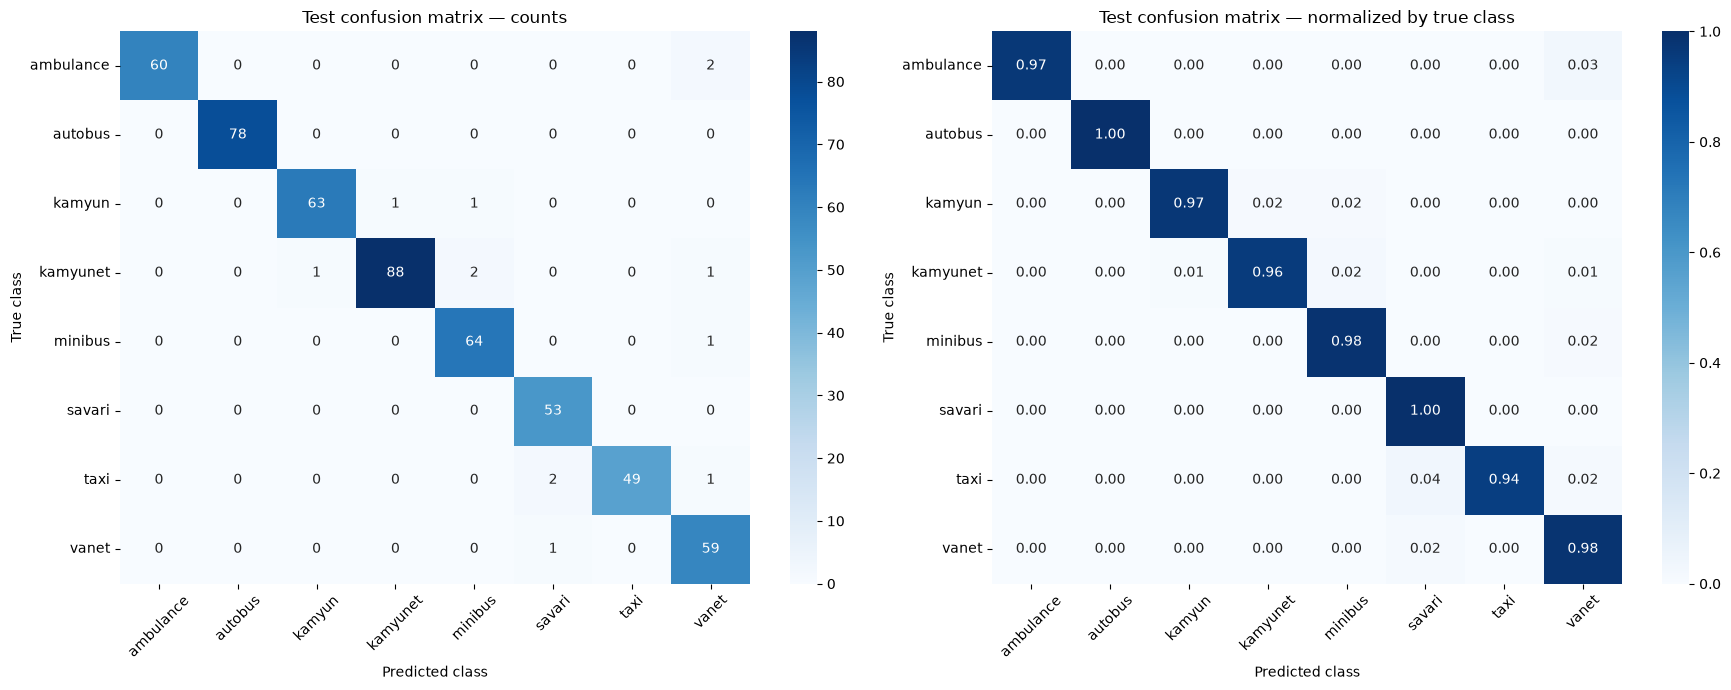

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\final_test\test_confusion_matrices.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = pd.read_csv(
    TEST_OUTPUT_DIR / "test_predictions.csv"
)

cm = confusion_matrix(
    predictions["true_class"],
    predictions["predicted_class"],
    labels=classes
)

cm_normalized = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[0]
)
axes[0].set_title("Test confusion matrix — counts")

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[1]
)
axes[1].set_title("Test confusion matrix — normalized by true class")

for ax in axes:
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.tight_layout()

figure_path = TEST_OUTPUT_DIR / "test_confusion_matrices.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)

,true_class,predicted_class,error_count
0,ambulance,vanet,2
1,kamyun,kamyunet,1
2,kamyun,minibus,1
3,kamyunet,kamyun,1
4,kamyunet,minibus,2
5,kamyunet,vanet,1
6,minibus,vanet,1
7,taxi,savari,2
8,taxi,vanet,1
9,vanet,savari,1


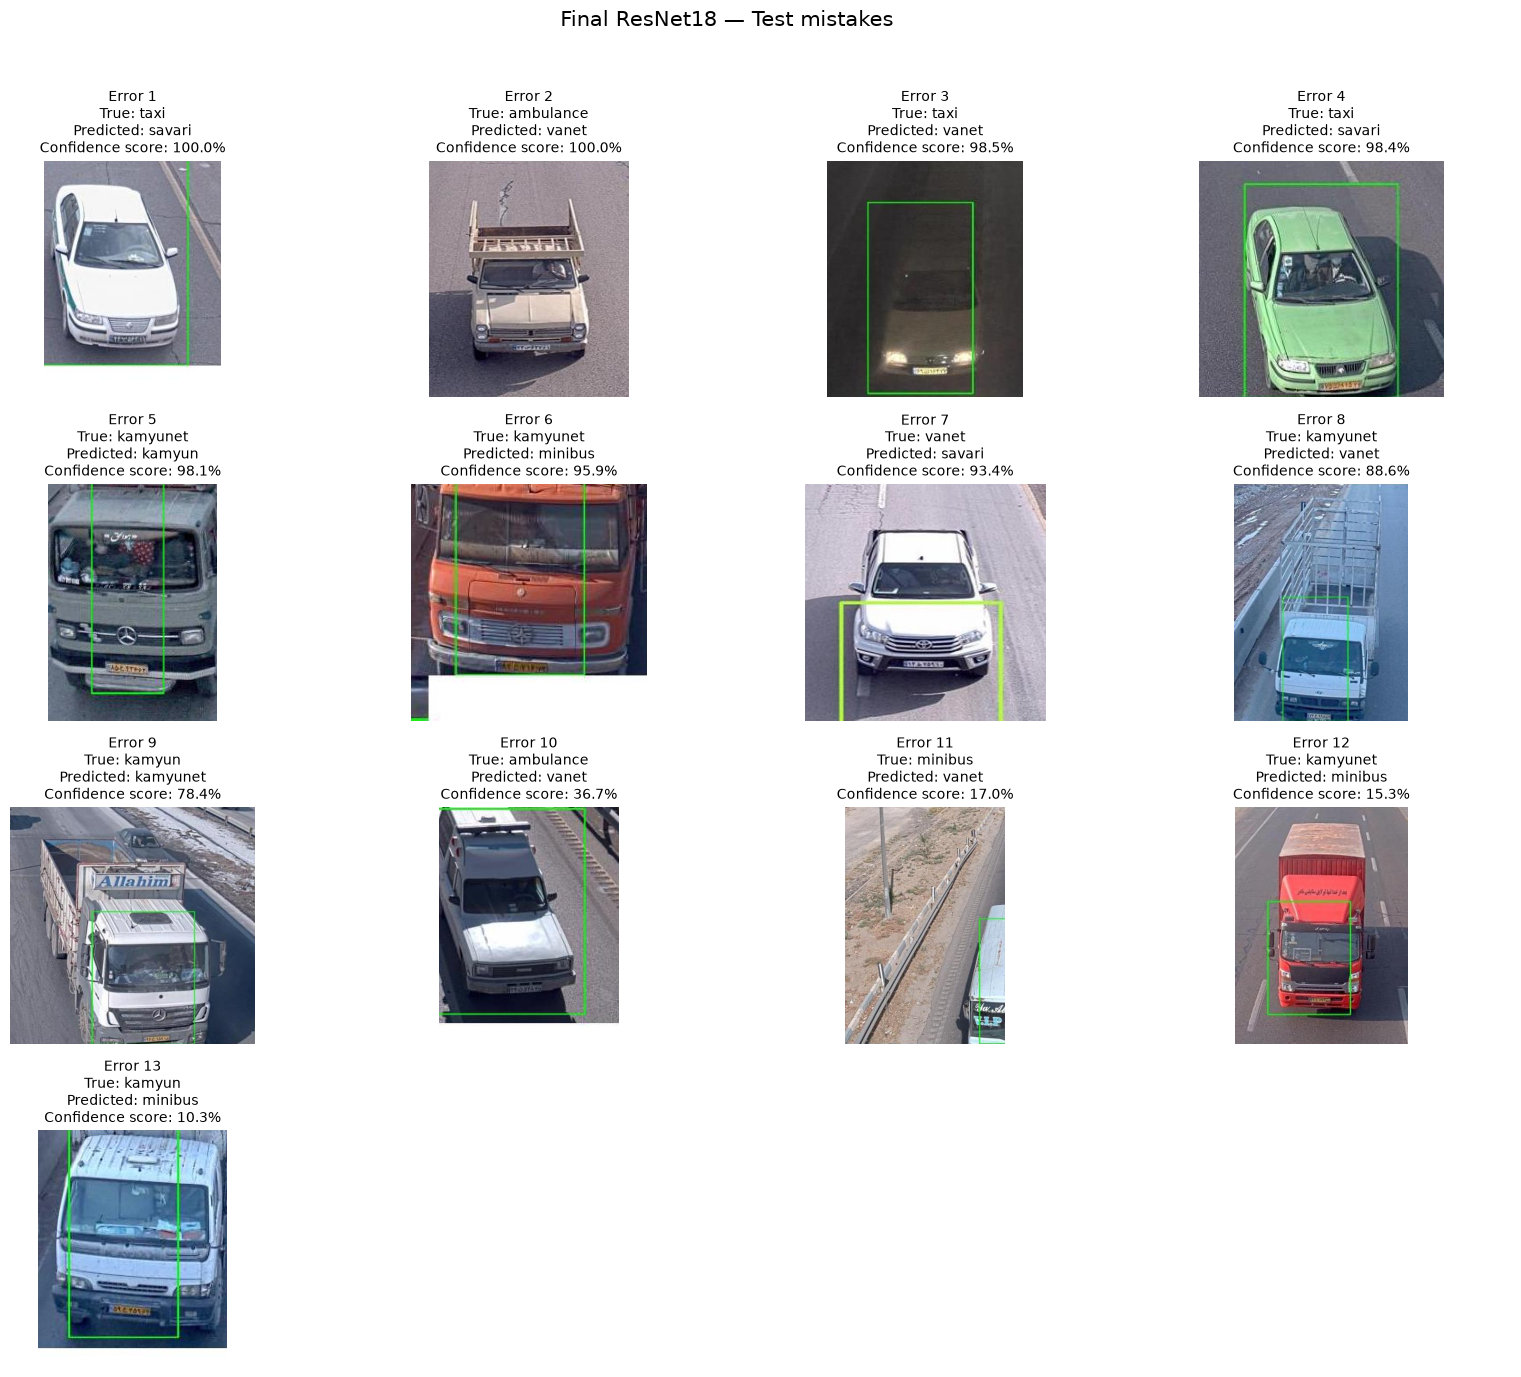

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\final_test\test_errors.png
Total test errors: 13


In [5]:
import math
from PIL import Image, ImageOps

predictions = pd.read_csv(
    TEST_OUTPUT_DIR / "test_predictions.csv"
)

errors = predictions[
    predictions["true_class"] != predictions["predicted_class"]
].copy()

errors = errors.sort_values(
    "confidence_percent", ascending=False
).reset_index(drop=True)

errors.to_csv(
    TEST_OUTPUT_DIR / "test_errors.csv",
    index=False
)

display(
    errors.groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="error_count")
)

if not errors.empty:
    columns = 4
    rows = math.ceil(len(errors) / columns)

    fig, axes = plt.subplots(
        rows, columns,
        figsize=(16, rows * 3.5),
        squeeze=False
    )

    for ax in axes.ravel():
        ax.axis("off")

    for index, row in errors.iterrows():
        ax = axes.ravel()[index]

        with Image.open(row["path"]) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            ax.imshow(image)

        ax.set_title(
            f"Error {index + 1}\n"
            f"True: {row['true_class']}\n"
            f"Predicted: {row['predicted_class']}\n"
            f"Confidence score: {row['confidence_percent']:.1f}%",
            fontsize=10
        )

    fig.suptitle("Final ResNet18 — Test mistakes", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    figure_path = TEST_OUTPUT_DIR / "test_errors.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Figure saved:", figure_path)

print("Total test errors:", len(errors))